# Week 4 Tasks

## Task 1

A 2-qubit circuit with a 90 degree phase difference visualised on the Q-sphere.

     ┌───┐     
q_0: ┤ H ├─────
     ├───┤┌───┐
q_1: ┤ H ├┤ S ├
     └───┘└───┘
Statevector([0.5+0.j , 0.5+0.j , 0. +0.5j, 0. +0.5j],
            dims=(2, 2))


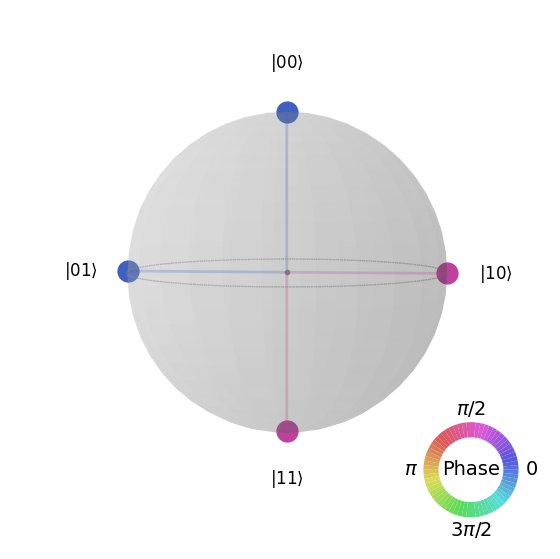

In [17]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere

qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)
qc.s(1)

print(qc)
state = Statevector.from_instruction(qc)
print(state)
plot_state_qsphere(state)

Reflection: The Q-sphere shows that all four basis states have equal probability, but `|10⟩` and `|11⟩` have a 90 degree phase shift, so their colours are different.

## Task 2

Density matrix for the same circuit.

DensityMatrix([[0.25+0.j  , 0.25+0.j  , 0.  -0.25j, 0.  -0.25j],
               [0.25+0.j  , 0.25+0.j  , 0.  -0.25j, 0.  -0.25j],
               [0.  +0.25j, 0.  +0.25j, 0.25+0.j  , 0.25+0.j  ],
               [0.  +0.25j, 0.  +0.25j, 0.25+0.j  , 0.25+0.j  ]],
              dims=(2, 2))
[0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j]


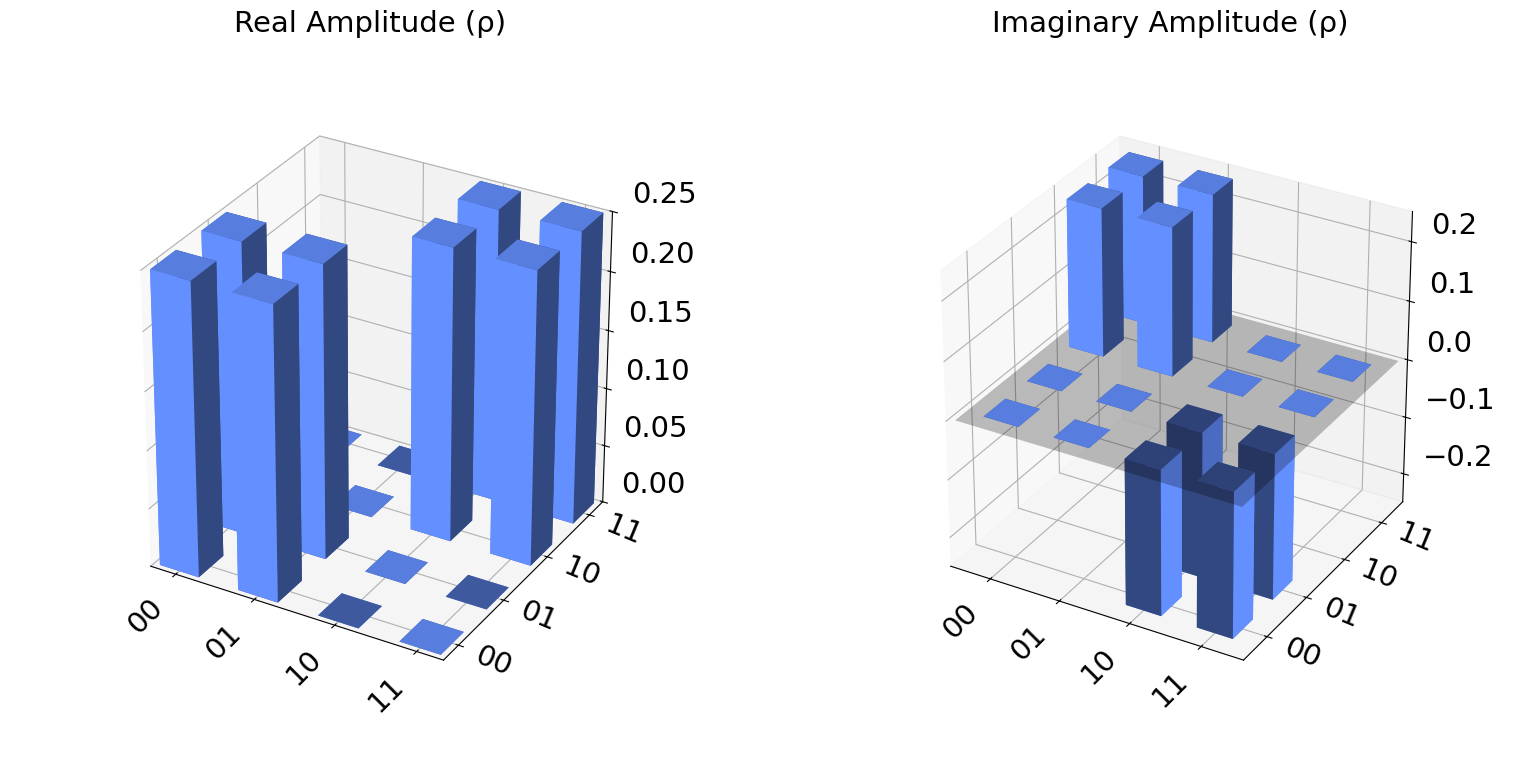

In [18]:
import numpy as np
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city

density_matrix = DensityMatrix.from_instruction(qc)
print(density_matrix)
print(np.diag(density_matrix.data))
plot_state_city(density_matrix)

Reflection: The diagonal elements represent measurement probabilities. The off-diagonal elements represent coherence and phase relationships between basis states.

## Task 3

Hand-written QASM circuit loaded and executed in Qiskit.

In [19]:
from pathlib import Path
import qiskit.qasm2
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator

possible_paths = [Path('Week4/my_random_circuit.qasm'), Path('my_random_circuit.qasm')]
qasm_path = next(path for path in possible_paths if path.exists())

print(qasm_path.read_text())
loaded_circuit = qiskit.qasm2.load(str(qasm_path))
print(loaded_circuit)

simulator = BasicSimulator()
compiled_circuit = transpile(loaded_circuit, simulator)
job = simulator.run(compiled_circuit, shots=100)
result = job.result()

print(result.get_counts())

OPENQASM 2.0;
include "qelib1.inc";
// Keep this in Qiskit; some other environments may require this line to be removed.

qreg q[3];
creg c[3];

h q[0];
x q[1];
s q[2];
cx q[0], q[2];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];

     ┌───┐        ┌─┐   
q_0: ┤ H ├──■─────┤M├───
     ├───┤  │  ┌─┐└╥┘   
q_1: ┤ X ├──┼──┤M├─╫────
     ├───┤┌─┴─┐└╥┘ ║ ┌─┐
q_2: ┤ S ├┤ X ├─╫──╫─┤M├
     └───┘└───┘ ║  ║ └╥┘
c: 3/═══════════╩══╩══╩═
                1  0  2 
{'010': 49, '111': 51}


Reflection: This task shows that a circuit can be written directly in QASM, loaded into Qiskit, printed, and executed without using the `dump` method.